<a href="https://colab.research.google.com/github/khalidsadi/1.8.25/blob/main/IMPLEMENTATION_AND_PERFORMANCE_ANALYSIS_OF_PARALLEL_MERGE_SORT_USING_PYTHON_MULTIPROCESSING_id_1000062861_khalidSadi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

size=   10,000  processes=1  time=  0.0207s  speedup= 1.00  efficiency= 1.00  correct=True
size=   10,000  processes=2  time=  0.0339s  speedup= 0.61  efficiency= 0.30  correct=True
size=   10,000  processes=4  time=  0.0533s  speedup= 0.39  efficiency= 0.10  correct=True
size=   50,000  processes=1  time=  0.1682s  speedup= 1.00  efficiency= 1.00  correct=True
size=   50,000  processes=2  time=  0.2212s  speedup= 0.76  efficiency= 0.38  correct=True
size=   50,000  processes=4  time=  0.1251s  speedup= 1.35  efficiency= 0.34  correct=True
size=  100,000  processes=1  time=  0.3413s  speedup= 1.00  efficiency= 1.00  correct=True
size=  100,000  processes=2  time=  0.4104s  speedup= 0.83  efficiency= 0.42  correct=True
size=  100,000  processes=4  time=  0.4324s  speedup= 0.79  efficiency= 0.20  correct=True
size=  500,000  processes=1  time=  2.7437s  speedup= 1.00  efficiency= 1.00  correct=True
size=  500,000  processes=2  time=  1.3654s  speedup= 2.01  efficiency= 1.00  correct=True

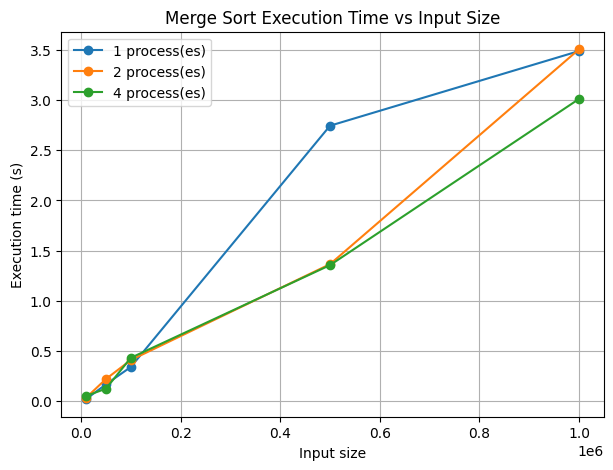

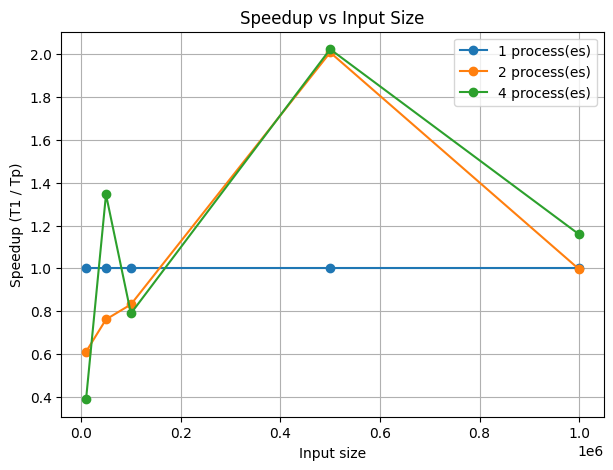

In [ ]:


import random
import time
import multiprocessing as mp
import csv



# 1. Data generation


def generate_random_data(n, seed=0):
    rng = random.Random(seed)
    return [rng.randint(0, 10_000_000) for _ in range(n)]



# 2. Normal (sequential) merge sort


def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result


def normal_merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = normal_merge_sort(arr[:mid])
    right = normal_merge_sort(arr[mid:])
    return merge(left, right)



# 3. Parallel merge sort
#    Strategy: split the array into `num_processes` roughly-equal
#    chunks, sort each chunk in its own process (worker calls the
#    same sequential merge sort above), then merge the sorted chunks
#    back together sequentially in the parent process.


def _sort_chunk(chunk):
    return normal_merge_sort(chunk)


def _split_into_chunks(arr, num_chunks):
    n = len(arr)
    chunk_size = (n + num_chunks - 1) // num_chunks
    return [arr[i:i + chunk_size] for i in range(0, n, chunk_size)]


def _merge_all(sorted_chunks):
    # Repeatedly merge pairs of sorted chunks until only one remains
    # (a simple k-way merge via pairwise reduction).
    chunks = list(sorted_chunks)
    while len(chunks) > 1:
        merged = []
        for i in range(0, len(chunks), 2):
            if i + 1 < len(chunks):
                merged.append(merge(chunks[i], chunks[i + 1]))
            else:
                merged.append(chunks[i])
        chunks = merged
    return chunks[0] if chunks else []


def parallel_merge_sort(arr, num_processes):
    if num_processes <= 1:
        return normal_merge_sort(arr)

    chunks = _split_into_chunks(arr, num_processes)

    with mp.Pool(processes=num_processes) as pool:
        sorted_chunks = pool.map(_sort_chunk, chunks)

    return _merge_all(sorted_chunks)



# 4. Benchmark harness

INPUT_SIZES = [10_000, 50_000, 100_000, 500_000, 1_000_000]
PROCESS_COUNTS = [1, 2, 4]


def run_benchmark(out_csv="parallel_merge_sort_results.csv"):
    rows = []
    baseline_times = {}  # size -> sequential (1-process) time, for speedup

    for size in INPUT_SIZES:
        data = generate_random_data(size, seed=size)  # fixed seed per size
        ground_truth = sorted(data)

        for p in PROCESS_COUNTS:
            t0 = time.perf_counter()
            result = parallel_merge_sort(data, p)
            elapsed = time.perf_counter() - t0

            correct = (result == ground_truth)
            if not correct:
                print(f"MISMATCH at size={size}, processes={p} !!")

            if p == 1:
                baseline_times[size] = elapsed

            speedup = baseline_times[size] / elapsed if elapsed > 0 else float("nan")
            efficiency = speedup / p

            rows.append({
                "input_size": size,
                "processes": p,
                "time_sec": round(elapsed, 4),
                "speedup": round(speedup, 3),
                "efficiency": round(efficiency, 3),
                "correct": correct,
            })

            print(f"size={size:>9,}  processes={p}  "
                  f"time={elapsed:8.4f}s  speedup={speedup:5.2f}  "
                  f"efficiency={efficiency:5.2f}  correct={correct}")

    with open(out_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f"\nSaved results to {out_csv}")

    return rows



# 5. Plotting (matplotlib is preinstalled on Colab)


def plot_results(rows):
    import matplotlib.pyplot as plt

    sizes = sorted(set(r["input_size"] for r in rows))
    processes = sorted(set(r["processes"] for r in rows))

    # Execution time vs input size, one line per process count
    plt.figure(figsize=(7, 5))
    for p in processes:
        ys = [r["time_sec"] for r in rows if r["processes"] == p]
        plt.plot(sizes, ys, marker="o", label=f"{p} process(es)")
    plt.xlabel("Input size")
    plt.ylabel("Execution time (s)")
    plt.title("Merge Sort Execution Time vs Input Size")
    plt.legend()
    plt.grid(True)
    plt.savefig("execution_time.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Speedup vs input size, one line per process count
    plt.figure(figsize=(7, 5))
    for p in processes:
        ys = [r["speedup"] for r in rows if r["processes"] == p]
        plt.plot(sizes, ys, marker="o", label=f"{p} process(es)")
    plt.xlabel("Input size")
    plt.ylabel("Speedup (T1 / Tp)")
    plt.title("Speedup vs Input Size")
    plt.legend()
    plt.grid(True)
    plt.savefig("speedup.png", dpi=150, bbox_inches="tight")
    plt.show()



if __name__ == "__main__":
    results = run_benchmark()
    plot_results(results)
